Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [2]:
NAME = "Angelina Podolako"
STUDENT_NUMBER = "s1125886"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Notebooks to make your assignments, it might remove the auto-grading metadata. To prevent this, please copy the answers back into the original notebook.
- Only type your answers in places where asked.   

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You can remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

### Assignment 4


## Deadline: November 27th, 23:59

Note: The workgroup of November 14th is canceled. To give you still two workgroups to work on this assignment, all further deadlines in the course will be moved one week.

In this assignment, we are going to do the following things:

- Kmeans clustering
- PCA
- Random forest
- AdaBoost

Due to request of your TA's, we've decided this time to do most of the plots using MatPlotLib and SeaBorn. Seaborn is a wrapper around Matplotlib, check out the documentation here: https://seaborn.pydata.org/.

In case you have not installed them yet, you can install them using the following cell:



In [131]:
# Uncomment the following line to install seaborn and matplotlib
#! pip install seaborn==0.12.2 matplotlib==3.7.1
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Move the penguin dataset from the last weeks to this directory again
my_penguin_path = "penguin.csv"
penguins = pd.read_csv(my_penguin_path)
penguins = penguins.dropna()

### Exercise 1.1.1

Using Seaborn, we can also make a scatter matrix; here, it is called a `pairplot.`
Take a look at the pair plot below. If we use k-means clustering using only two features, on which two features do you think it is hardest to cluster correctly, if the intended outcome is that the clusters represent the penguin species?

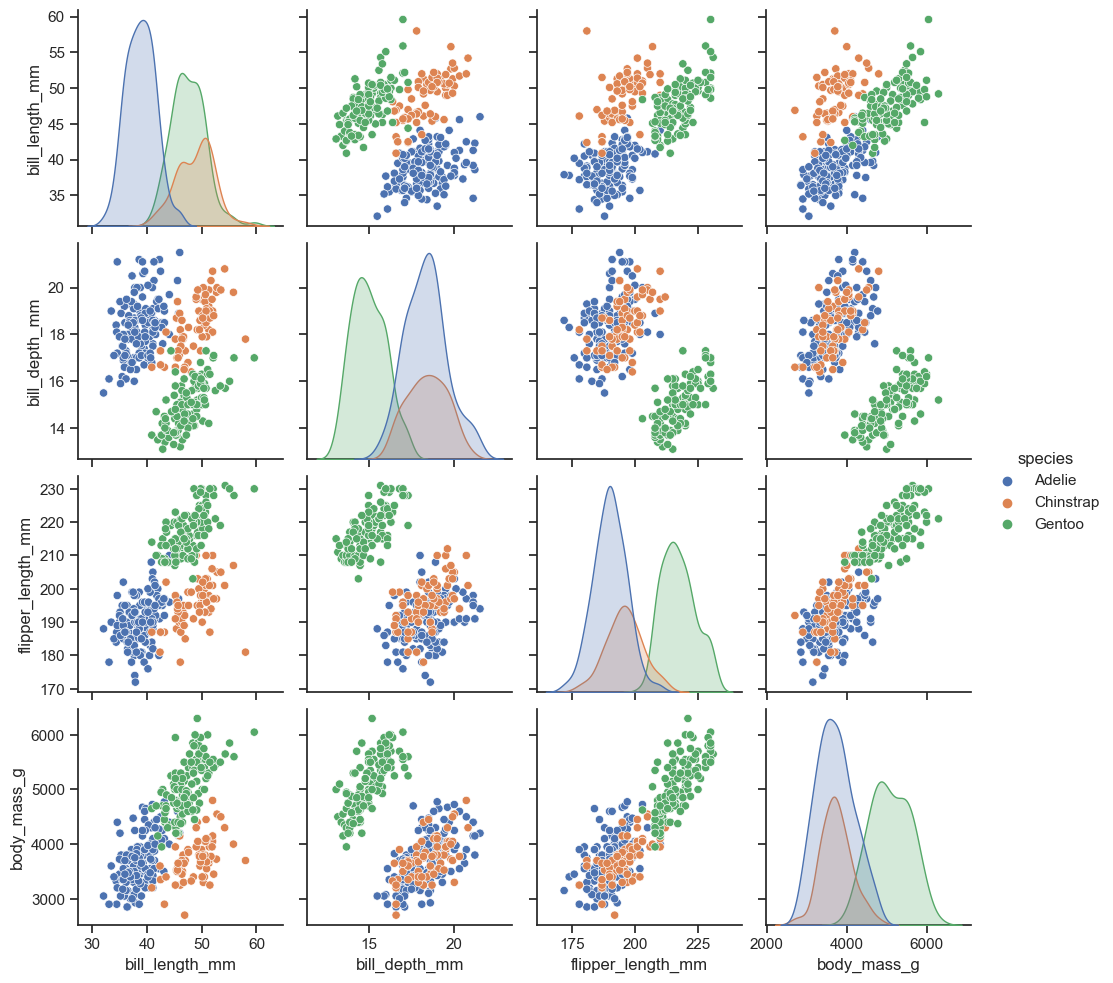

In [136]:
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

sns.set_theme(style="ticks")
sns.pairplot(penguins, hue="species")

The most difficult pair of features for K-means clustering are 1)flipper_length_mm and bill_depth_mm or 2)flipper_length_mm and body_mass_g or 3)body_mass_g and bill_depth_mm , since clusters for different penguin species overlap strongly, which makes it difficult to accurately separate, especially Adelie and Chinstrap has near similar centres. 
But the hardest of them are flipper_length_mm and body_mass_g since all three graphs extremely close to each other,and the red one is completely on top of the blue one.

## Exercise 1.1.2
We choose to try to cluster Body Mass and Bill Length, inspect the plot below:

To make sure the values of the two features are approximately in the same order, we divide bill_length by 100.

[Text(0.5, 0, 'body_mass_g'), Text(0, 0.5, 'bill_length_mm')]

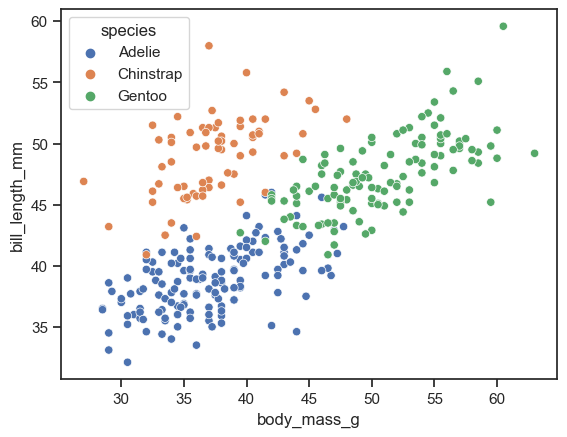

In [139]:
x_features = ["body_mass_g", "bill_length_mm"]
penguin_X = penguins[x_features].to_numpy().reshape(-1, 2) #cols x_fe-tomassive-to2d(-1row,2col)=1col-mass=2c-len

# normalizing so the values are in approximately similar dimensions
penguin_X[:, 0] = penguin_X[:, 0] / 100 #mass/100=comfsize

sns.scatterplot(x=penguin_X[:, 0], y=penguin_X[:, 1], hue=penguins["species"]).set(
    xlabel=x_features[0], ylabel=x_features[1]
)#dot diag(x,y, color dots as specie,).set(labels)

### Exercise 1.1.2

Given the previous plot, we can estimate the 3 means to be around the coordinates (35,35), (42,45) and (55,50).

Given a numpy array with these three means, assign each data point in `penguin_X` to the closest to the np array `assigned_cluster.`
As a distance metric, use the Euclidian distance, for example, using https://numpy.org/devdocs/reference/generated/numpy.linalg.norm.html . 

This 1-dimension array has a length of $N$, and for each datapoint assigns either 0, 1 or 2, depending if it's closest to the 0th, 1st or 2nd element of `proposed_means`.

In [141]:
proposed_means = np.array([[35, 35], [42, 45], [55, 50]])
assigned_cluster = None


# YOUR CODE HERE
assigned_cluster = np.zeros(penguin_X.shape[0])
for i, dot in enumerate(penguin_X): #for index, dotitself in matrix dots
    distance_to_proposed_means = np.linalg.norm(proposed_means - dot, axis=1)#norm(leng) of matrix/vec=distance between dots
    assigned_cluster[i] = np.argmin(distance_to_proposed_means) #nearest to centre =index of min from distance

print(assigned_cluster.shape)

(333,)


In [142]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

<Axes: xlabel='body_mass_g', ylabel='bill_length_mm'>

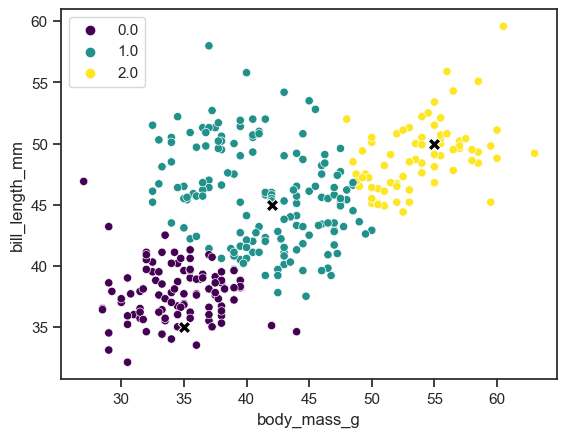

In [143]:
# Use the following plot to inspect if you assigned the clusters correctly

# x and y, colored with cluster colors
# Even if you implemented the above correctly, it will look a little bit different than the plot above
sns.scatterplot(
    x=penguin_X[:, 0], y=penguin_X[:, 1], palette="viridis", hue=assigned_cluster
).set(xlabel=x_features[0], ylabel=x_features[1])
# the dediced means
sns.scatterplot(
    x=proposed_means[:, 0], y=proposed_means[:, 1], marker="X", s=80, color="black"
)

### Exercise 1.1.3

Now using the code you made in the exercise above, finish the class KMeans. 

Finish the `assign_to_cluster` method, which, given a Numpy array `X` and the `self.centroids`, will assign all datapoints to the nearest cluster. (Note, you can reuse most of your code above. Just make sure you change the variable names to the correct ones)


In [145]:
class KMeans:
    n_clusters = 0
    centroids = None

    def __init__(self, n_clusters):
        self.n_clusters = n_clusters

    def assign_to_cluster(self, X):
        ### Given X with dimension NxM and self.centroids, this will return a
        assigned_cluster = None
        # YOUR CODE HERE
        assigned_cluster = np.zeros(X.shape[0])
        for i, dot in enumerate(X): #for index, dotitself in matrix dots
            distance_to_proposed_means = np.linalg.norm(self.centroids - dot, axis=1)#norm(leng) of matrix/vec=distance between dots
            assigned_cluster[i] = np.argmin(distance_to_proposed_means) #nearest to centre =index of min from distance

        return assigned_cluster

    def compute_new_mean(self, X, assigned):
        mean_stack = []
        for i in range(self.n_clusters): #for each cluster by index in
            new_mean = np.mean(X[assigned == i], axis=0) #find all dots to this cluster, compute mean for these dots
            if any(np.isnan(new_mean)): #if mean = nan -then old centre
                mean_stack.append(self.centroids[i])
            else:
                mean_stack.append(new_mean) #if non nan - then new mean
        return np.stack(mean_stack) #new list od centres

    def fit(self, X, steps):
        # also adding the plotting:
        plot_dim_x = 3
        plot_dim_y = 4
        fig, axes = plt.subplots(plot_dim_x, plot_dim_y, figsize=(15, 15), sharey=True) #12subgraphs

        # Fitting the k-means
        N, d = X.shape #n=dots zise, d= feature size
        all_mins = np.min(X, axis=0) 
        all_maxes = np.max(X, axis=0)
        self.centroids = (all_maxes - all_mins) * np.random.random_sample( #diff betw max min for each feature=predeli for cluster
            (self.n_clusters, d) #matrix of randon numbs(numb of cluster for which needs centres, numb of featur)
        ) + all_mins  #(allmax-allmin) * (each el 0 to 1) +smeshenie na min znach features = raspolozh kak i X data
        assigned = []
        all_centroids = []

        for step in range(steps): 
            all_centroids.append(self.centroids)
            # Assign clusters
            assigned = self.assign_to_cluster(X)
            # Update the mean
            self.centroids = self.compute_new_mean(X, assigned)

            # Keep track of all centroids for plotting
            stacked_centroids = np.stack(all_centroids)

            # Making the subplots
            apx, apy = (int(step / plot_dim_y), step % plot_dim_y)
            # plotting the x and y
            sns.scatterplot(
                ax=axes[apx, apy], x=X[:, 0], y=X[:, 1], palette="viridis", hue=assigned
            ).set(xlabel=f"{x_features[0]}, step {step}", ylabel=x_features[1])
            # Plotting the k means over.
            for dim in range(stacked_centroids.shape[1]):
                sns.lineplot(
                    ax=axes[apx, apy],
                    x=stacked_centroids[:, dim, 0],
                    y=stacked_centroids[:, dim, 1],
                    color="black",
                    linestyle="dashed",
                    marker="X",
                    markersize=10,
                    markerfacecolor="black",
                )

        return (assigned, np.stack(all_centroids)) #massive with index for cluster, all centres for all iterations

### Exercise 1.1.3

Make an instance of the class KMeans with 3 clusters, and cluster Penguin_X with 12 steps.
We have code that plots the moving of the clusters inside this class.

Run it a few times, so see how different random initializations can change the end results. Note that we do a very naive style of initializing the centroids here. It could be that you run into an error when one of them initializes in a weird spot. 

Play around with different values for clusters.
You can change the number of steps as well, but make sure you change plot_dim_x and plot_dim_y in the above code then as well, such that plot_dim_x * plot_dim_y = n_clusters


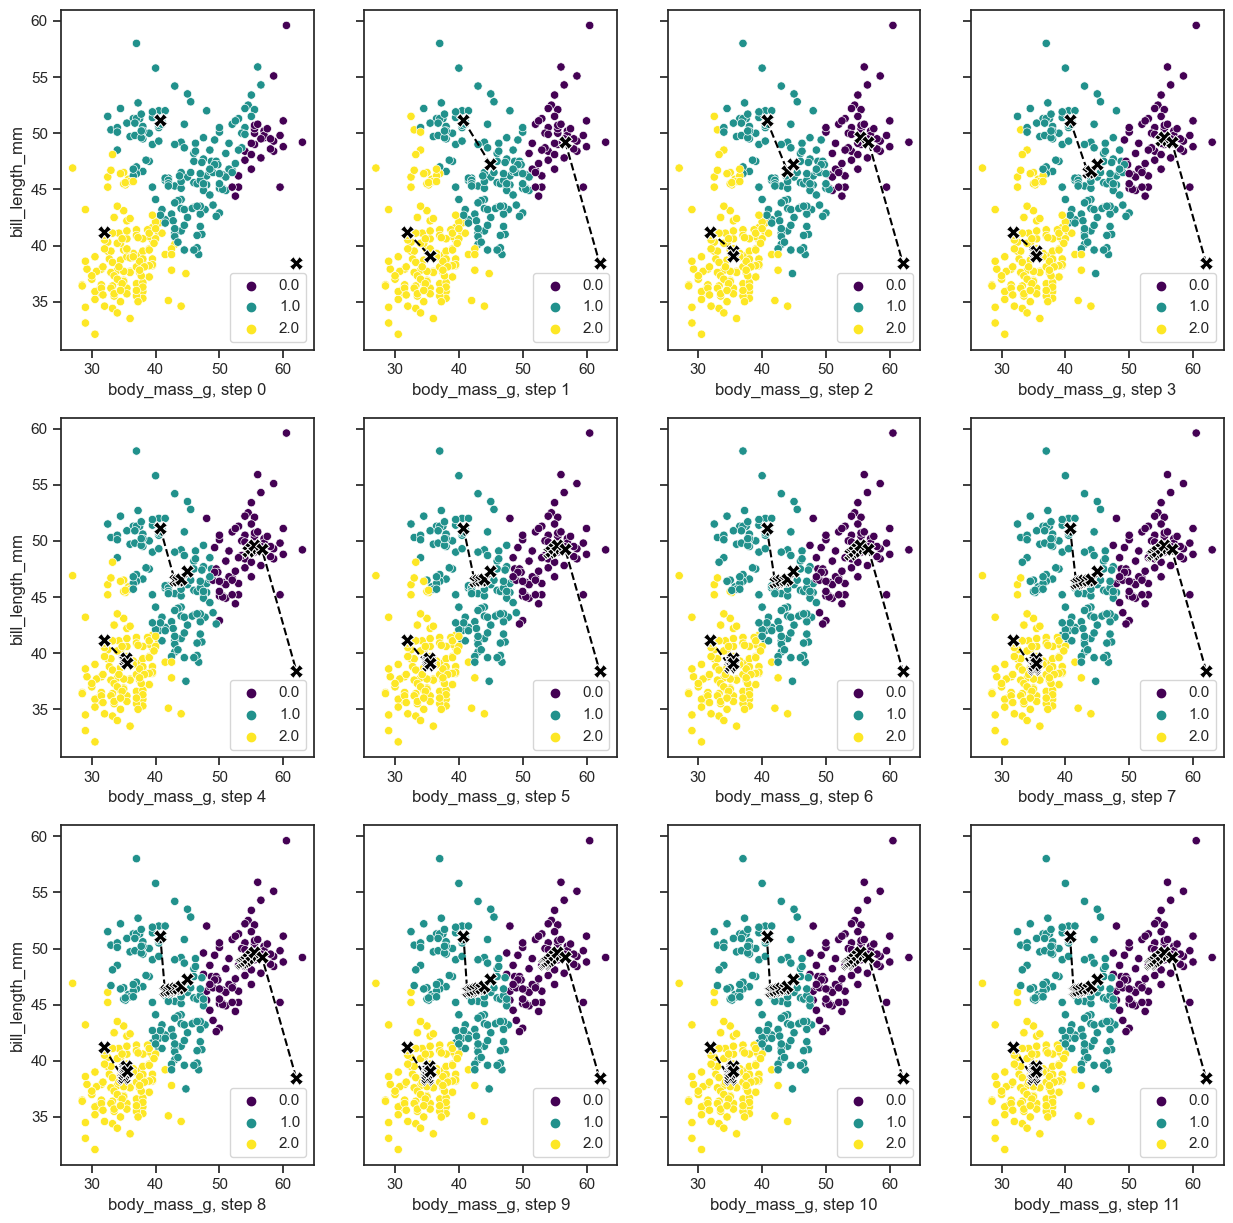

In [147]:
n_clusters = 3
steps = 12  #plot_dim_x * plot_dim_y = ?n_clusters?(maybe steps?)

# YOUR CODE HERE
kmeans = KMeans(n_clusters) #instance of kmeans with n clusters
#kmeans returns assigned(which cluster to each dot) and all_centroid(all cnetres for each iteration)
assigned, all_centroids = kmeans.fit(penguin_X, steps) #use kmeans to penguin_X, with n steps

### Exercise 1.2.1

In this exercise, we will compute the PCA using singular value decomposition. 

Remember that using SVD, we can break up a Matrix into three parts:

$$SVD(X) = U \Sigma W^T $$

We can then apply PCA to our matrix X by computing

$$ X \cdot W$$


Using [np svd](https://numpy.org/doc/stable/reference/generated/numpy.linalg.svd.html), compute the U, sigma, Wt on 
centered_penguins. Then compute $ X \cdot W$ as `pca_penguins`.

In [149]:
U, sigma, Wt = None, None, None #U=eigenvec(AA^T)-left, s=diag of sing val matrix(roots of eigenval), W=eigenvec(A^TA)-right
centered_penguins = penguin_X - penguin_X.mean(axis=0) #actual - mean of col
pca_penguins = None
# YOUR CODE HERE
U, sigma, Wt = np.linalg.svd(centered_penguins)
pca_penguins = centered_penguins.dot(Wt.T) #dot to matrix muplitplication

### Exercise 1.2.2
Use the plot below to inspect your result of the PCA.
We've assigned colors over the scatterplot based on the index of the data point.
They do not really represent anything; they just make it easier to see which data point moved where. 



Extra: We're using this color palette called Viridis here. It's supposed to be friendly for people who are colorblind.
You can read more about it [here](https://cran.r-project.org/web/packages/viridis/vignettes/intro-to-viridis.html)


One eigenvector is [0.88268469 0.46996567], another one is [4.69965675 8.82684692]


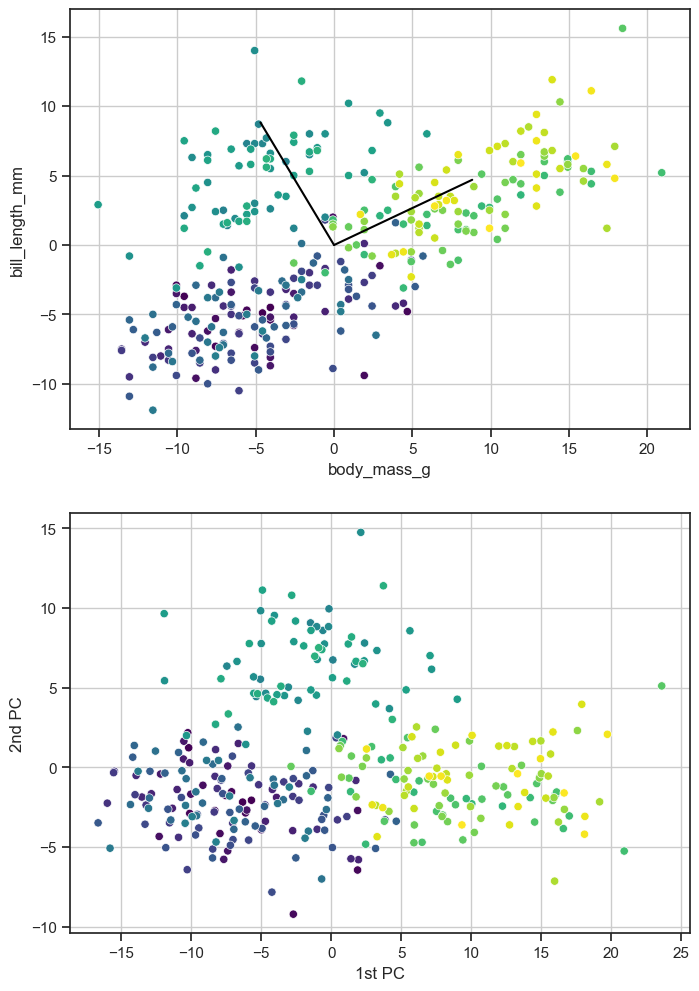

In [155]:
Wbig = (
    Wt.T * 10
)  # Transposing W^t to get W, and also multiplying them so they are more visable


print(f"One eigenvector is {Wt[0]}, another one is {Wbig[1]}")

fig, axes = plt.subplots(2, 1, figsize=(8, 12))
sns.scatterplot(
    ax=axes[0],
    x=centered_penguins[:, 0],
    y=centered_penguins[:, 1],
    hue=range(len(centered_penguins)),
    palette="viridis",
    legend=False,
).set(xlabel=x_features[0], ylabel=x_features[1])
axes[0].grid(True)



sns.lineplot(ax=axes[0], x=[0, Wbig[0, 0]], y=[0, Wbig[1, 0]], color="black")
sns.lineplot(ax=axes[0], x=[0, Wbig[0, 1]], y=[0, Wbig[1, 1]], color="black")
sns.scatterplot(
    ax=axes[1],
    x=pca_penguins[:, 0],
    y=pca_penguins[:, 1],
    hue=range(len(centered_penguins)),
    palette="viridis", #colorblind palette
    legend=False,
).set(xlabel="1st PC", ylabel="2nd PC")
axes[1].grid(True)


### Exercise 1.2.2
We'll also take a look at the PCA results using the package of SKlearn, this time we will do it on all numeric features of the penguin dataset.

When considering the elbow, which integer between 0 and 5 would you pick as the optimal number of principal components to represent the data?

When looking at the 1st principle component, which feature explains the most _variance_ for the penguin plot?

The penguin features we use are ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
The weight vectors for the 1st pc are [ 0.46061135 -0.10204379  0.13970385  0.87057859]
The weight vectors for the other pc are 
 [[ 0.88508549  0.10067345 -0.01435154 -0.45418341]
 [-0.03271895  0.97393421 -0.16023469  0.1571829 ]
 [-0.05822659  0.17579553  0.97703721 -0.10537496]]


[Text(0.5, 0, 'Number of PCs'),
 Text(0, 0.5, 'Explained variance'),

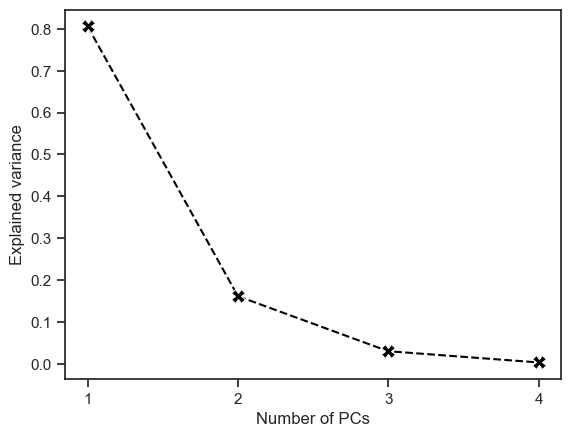

In [159]:
from sklearn.decomposition import PCA

print(f"The penguin features we use are {features}")
# Lazy scaling of the penguin features, making sure everything is approximately between 0.1 and 1
penguin_scaled = penguins[features] * [0.01, 0.01, 0.001, 0.0001] #multiplier -data more similar scales.
pca = PCA(n_components=4) #PCA-analyse main components, save 4
pca.fit(penguin_scaled) #compute main components for scale (data=penguin_scaled)
print(f"The weight vectors for the 1st pc are {pca.components_[0]}")

print(f"The weight vectors for the other pc are \n {pca.components_[1:]}")

sns.lineplot(
    x=range(1, 5),
    y=pca.explained_variance_ratio_, #massive-info-how much disperisa is explained by each PC; sum=1
    color="black",
    linestyle="dashed",
    marker="X",
    markersize=10,
    markerfacecolor="black",
).set(xlabel="Number of PCs", ylabel="Explained variance", xticks=range(1, 5))

In [160]:
elbow_value = -1  # Substitute this value with an integer between 0 and 5
most_variance_1st_PC = "hair_length_cm"  # Substitute this variable with in string form

# YOUR CODE HERE
elbow_value = 2  # Substitute this value with an integer between 0 and 5
most_variance_1st_PC = "body_mass_g"  # Substitute this variable with in string form

In [161]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.2.3
Below, we've plotted the penguins, when transformed to the first and second principle component. Investigate the plot. When compared to the scatter matrix we made before in exercise 1.1.1, what do you notice?


[Text(0.5, 0, '1st PC'), Text(0, 0.5, '2nd PC')]

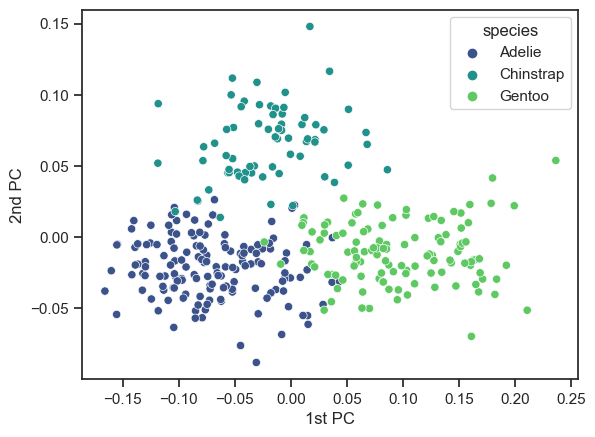

In [163]:
projected_penguins = pca.transform(penguin_scaled)
sns.scatterplot(
    x=projected_penguins[:, 0],
    y=projected_penguins[:, 1],
    hue=penguins["species"],
    palette="viridis",
).set(xlabel="1st PC", ylabel="2nd PC")

The graphs are similar, the main feature is that this graph seems to be rotated a little more. Other values are also used on axes that are less than 15 times on the x axis and 9 times on the y axis. Also, the data looks like it is slightly more compressed, especially on the x axis

### Exercise 1.3

One fun application for clustering is compressing the number of colors used in a picture.

Let us use both k-means clustering on a picture of a penguin.

For that, we first load a png of a penguin.
Pictures are nothing more than an $N\times M \times 3$
matrix, where $N\times M$ represent the number of pixels, and the 3 represents the 3 values for Red, Green and Blue (in that order), which are represented with an integer between 0 and 255.

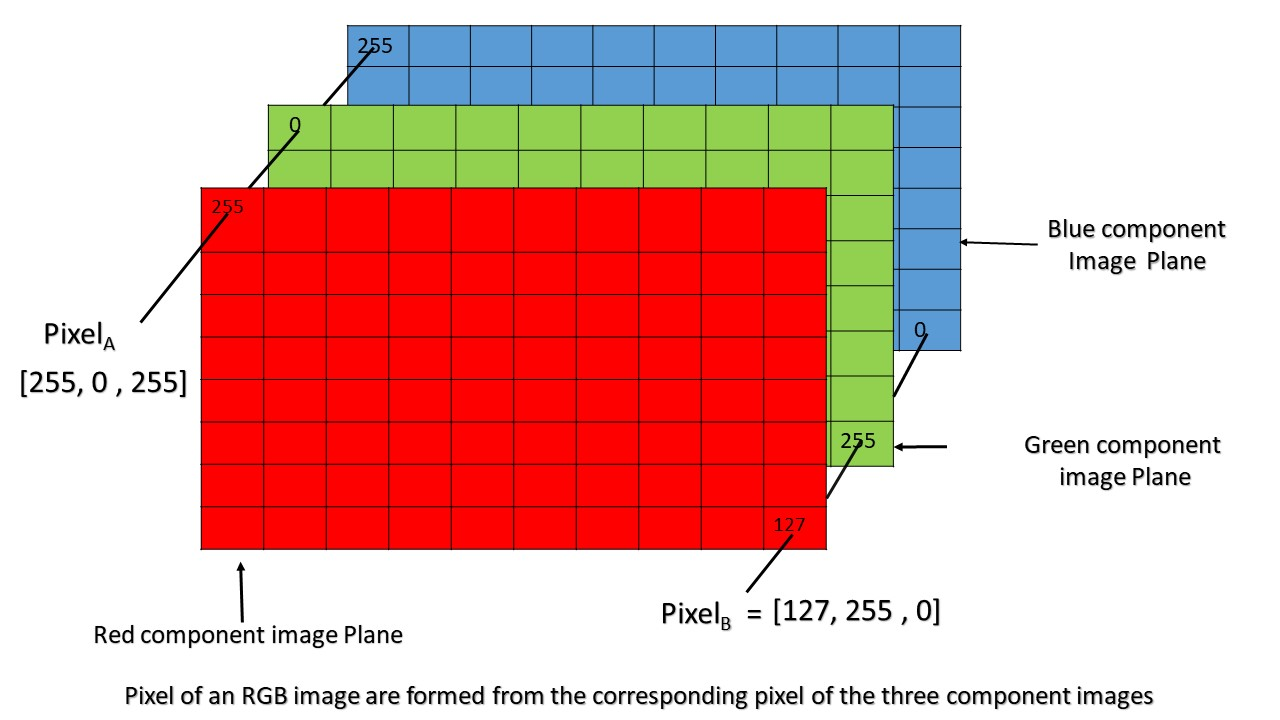

We can load in a picture and convert it to an numpy array. 

In [166]:
from PIL import Image

# Opening a .png
img = Image.open("penguin_picture.png")
# Converting to a numpy array
penguin_array = np.asarray(img)

### Exercise 1.3.1

Here we plot the penguin array using `plt.imshow`.
Explore the dimensions and contents of `penguin_array`, save the red values as `penguin_red_channel` and plot these

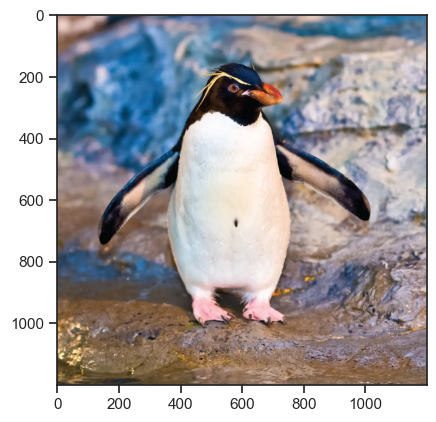

In [168]:
import matplotlib.pyplot as plt

imgplot = plt.imshow(penguin_array) #shape = (N,M,3) = NM-photo size, 3-RGB

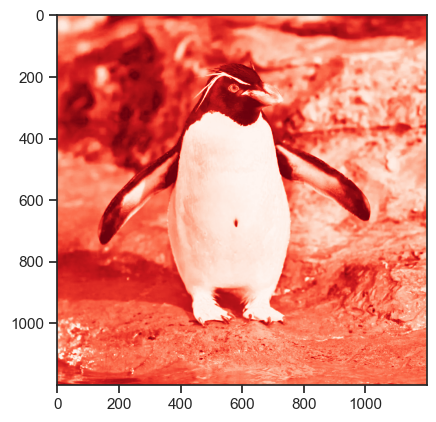

In [169]:
penguin_red_channel = None

# YOUR CODE HERE
penguin_red_channel = penguin_array[:, :, 0] #photo_save_these_params(height,width,3) -> 0-R 1-G 2-B

imgplot = plt.imshow(penguin_red_channel, cmap="Reds_r")

In [170]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

## Exercise 1.3.2

To be able to cluster the color values, we need to first convert this matrix to a $(N\cdot M)\times 3$ matrix. Using shape and reshape, reshape the penguin array with shape (1200x1200x3) to a matrix with shape 
(1440000x3). 

In [175]:
reshaped_penguin_array = None

# YOUR CODE HERE
reshaped_penguin_array = penguin_array.reshape(-1,3) #-1 -how much rows needs to be to have matrix with 3 cols
print(reshaped_penguin_array.shape)

(1440000, 3)


In [179]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.3.3

Using the [sklearn KMmean package](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html), cluster the color values in the image. The input will be this (1440000,3) reshaped_penguin_array we just made. Call the class instance of KMeans `kmeans`. 

Make a np array called `predicted_penguins`, where using `reshaped_penguin_array`, you predict the cluster each pixel belongs to. This will result in a (1440000,) vector, where each pixel is assigned a number between 0 and n_clusters-1



In [183]:
from sklearn.cluster import KMeans

n_clusters =100
kmeans = None
predicted_penguins = None

# YOUR CODE HERE
kmeans = KMeans(n_clusters)
kmeans.fit(reshaped_penguin_array) 

predicted_penguins = kmeans.predict(reshaped_penguin_array) 

In [185]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.3.4
Make a matrix compressed_penguin of shape 1200x1200x3 which for each pixel hold the value of the mean it belongs to. 

First, using `kmeans.cluster_centers_`, create an np array of shape n_cluster x 3 where every value in `kmeans.cluster_centers_` is rounder off to the nearest integer, and save it as `mean_color_values`. This is, because when plotting RGB values, all three values have to be integers between 0 and 225. 

Then, for each value in predicted_penguins, assign the closest value, and convert it back to a (1200x1200x3) array where each coordinate represents the value of which mean it clusters to. 

(So if the pixel at coordinate [2,5] belongs to the mean with color value [155, 255, 0],  compressed_penguin[2,5,0] = 155, compressed_penguin[2,5,1] = 255, compressed_penguin[2,5,2] = 0 )


Play around with the values of n_clusters to see the difference. 

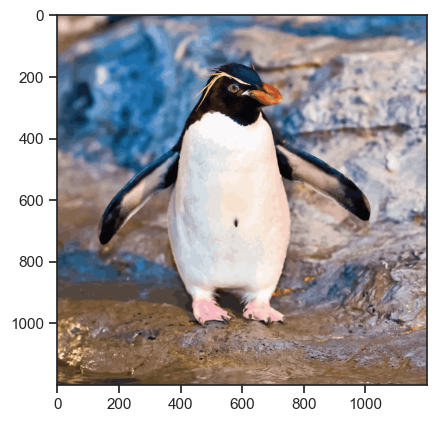

In [191]:
mean_color_values = None
compressed_penguin = None

# YOUR CODE HERE
mean_color_values = np.round(kmeans.cluster_centers_).astype(int) #array(n_cluster*3(RGB)) - val in centres rounded to nearest(becos - RGP are int 0-256)
#matrix_means[predict_index] -- for each el in predicted - choose color from means
compressed_penguin = mean_color_values[predicted_penguins].reshape(penguin_array.shape) #eachclusetr_with_color[cluster_index_foreach_pixel].reshape(orriginal.shape)

imgplot = plt.imshow(compressed_penguin)

In [192]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

# Part for WEEK 9:

Note, this part is to be done after you have attended the 9th lecture. You can work ahead, but we can't promise that the TA's can already help you with this part. 

## Exercise 2.1

In this exercise, we will ourself make a random forest tree, using the SKlearn implementation of decision trees.
To be able to better see the difference in overfitting between a decision tree and random forest, 
we will create a synthetic dataset. (Unfortunately, as we've seen before, our favorite Penguin dataset is too easy to see a difference between algorithms.)
We've already done the train/test split for you:

In [194]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn import tree

number_clfs = 50 # number of classifiers we will make later - numb of trees (in random forest)
n_features = 50 # number of features for our fake dataset
n_classes = 2 # Number of classes for our fake dataset
X, y = make_classification(
    n_samples=1000, n_features=20, n_classes=n_classes, random_state=42
) #x= matrix(1200*20), y= vecotr(1000,)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

### Exercise 2.1.1

Create your own function for fitting a random forest.

Given your dataset X_train of size (670,20), we want to downsample this to a smaller array of shape number_samples =200, number_features = 8 for our bagging. 

Create sample of your X_train and y_train with shape (200,8) and (200,) called `random_X` and `random_y`.
Fit an instance of a decision tree called `clf` on this subset.

The returned array `clfs` should be the random forest, which is a list of dictionaries with both models (so `clf`) and the random features used in that model.

For the Decision tree, you can just use the default settings for this exercise. 

In [196]:
def fit_a_forest(X, y, number_clfs, number_samples, number_features):
    clfs = [] #count trees in random forest
    N, m = X.shape
    for i in range(number_clfs):
        random_samples = np.random.choice(N, number_samples) #choose num_sample(n) trees from X to fit
        random_features = np.random.choice(m, number_features, replace=False) #choose num_feat(n) features from m to fit + without replacement
        # YOUR CODE HERE
        random_X = X[random_samples][:, random_features] #choose rows from X, that are =indexes from rand sample; cols of these rows
        random_y = y[random_samples]
        
        clf = tree.DecisionTreeClassifier()
        clf.fit(random_X, random_y)
        
        clfs.append({"model": clf, "features": random_features}) 
    return clfs #random forest - list of dics - model+features

In [238]:
# Fitting a forest

number_samples = 200
number_features = 8

clfs = fit_a_forest(X_train, y_train, number_clfs, number_samples, number_features)

In [223]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.2

Make a function that, given this random forest, predicts the most likely class for each item, using majority voting.

You can use np array preds, which is an empty array with 0s, to count how often the classifier predicts class 0 and class 1.
It is probably the easiest to do this with a nested for-loop, where you fill each element of the np array `preds`.
If, for example for your first datapoint, class 0 is predicted 20 times and class 1 is predicter 30 times, this will result in `preds[0] = [20,30]`

You can then use Numpy argmax to decide which class got the most votes, and for example return it as the numpy array final_pred.
For the example above, since class 1 gets the majority of votes (30 vs 20), then `final_preds[0]=1`

In [226]:
def predict_with_forest(forest, X, n_classes=2):
    preds = np.zeros((X.shape[0], n_classes)) #to count votes for classes
    final_pred = None
    # YOUR CODE HERE
    for clf in forest:
        selected_features = clf['features'] #feutres used in classifier lerning -because learned on 8, but uses 20 
        X_selected_features = X[:, selected_features] #select only these features
        
        prediction = clf['model'].predict(X_selected_features) # predicts class for sample = clf=dict model-classifier .predicton model
        
        for i, pred in enumerate(prediction): #pred = 0 or 1
            preds[i, pred] += 1 #preds(i=row, pred=col_=+1 vote for class was predictes in tree
    
    final_pred = np.argmax(preds, axis=1) #max = index  of class with max votes per row             
    return final_pred

In [240]:
from sklearn.metrics import confusion_matrix

# Prediction using your function predict_with_function
final_pred_train = predict_with_forest(clfs, X_train)
final_pred_test = predict_with_forest(clfs, X_test)

print(f"Confusion matrix on train: \n {confusion_matrix(y_train, final_pred_train)}")
print(f"Confusion matrix on test: \n {confusion_matrix(y_test, final_pred_test)}")

Confusion matrix on train: 
 [[323  14]
 [ 24 309]]
Confusion matrix on test: 
 [[148  15]
 [ 30 137]]


In [242]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.1.3

We also fit a normal decision tree in the cell below:
Compare the confusion matrix of fitting a decision tree on train and test, and fitting a forest on train and test.
What difference do you notice?

In [245]:
clf = tree.DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

pred_with_only_one = clf.predict(X_test)
pred_with_only_one_train = clf.predict(X_train)


print(f"Confusion matrix on train: \n {confusion_matrix(y_train, pred_with_only_one_train)}")
print(f"Confusion matrix on test: \n {confusion_matrix(y_test, pred_with_only_one)}")

Confusion matrix on train: 
 [[337   0]
 [  0 333]]
Confusion matrix on test: 
 [[145  18]
 [ 25 142]]


Confusion matrix : 
 (TP  FP
  FN  TN)
  We can see that on trian data second method (with only one tree) works better since  there are only TP and TN result, but we do not have false result on train data (look like overfitting). At same time it has slightly worse result on test data.
  When our method with random forest has more errors (False Negatives and Positives answers) in train data. But has less mistakes in test data, that shows that with regulating numb of features and some other thing we can get better results.

### Exercise 2.2

The following exercise will be a bit more free in it's execution, you will be putting the things learned in the previous exercises into practice. 

We will be using the [Mushroom dataset shared by Kaggle](https://www.kaggle.com/code/dileeppatchaone/poisonous-mushroom-g-o-a-t
). This is a dataset with information about mushrooms, where the goal is to predict if this mushroom is poisonous (p) or edible (e). 

Because the original Dataset consists of over 3 million lines, we decided to give you a smaller sample, to make sure everyone is able to run everything on their personal devices. 

Note: If you are using parts of code shared on the kaggle compition itself, that is allowed, but make sure to cite your sources. 

In [249]:
# Take a look at the mushrooms:
mushrooms_train = pd.read_csv("train_mini.csv")

print(mushrooms_train.columns)
mushrooms_train

Index(['id', 'class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color',
       'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color',
       'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color',
       'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color',
       'habitat', 'season'],
      dtype='object')


,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,...,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,...,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,99994,e,10.58,p,i,n,t,e,NaN,p,...,NaN,y,w,NaN,NaN,t,p,NaN,d,a
99995,99995,e,9.26,x,h,n,f,p,d,y,...,NaN,s,n,NaN,NaN,f,f,NaN,h,a
99996,99996,p,7.01,x,t,n,f,s,NaN,n,...,NaN,y,n,NaN,NaN,f,f,NaN,d,a
99997,99997,p,6.89,f,h,e,f,x,d,w,...,b,NaN,w,NaN,NaN,f,f,NaN,d,a


### Exercise 2.2.1

Compute the ratio of missing data for all features, and get a list of all features called `use_features` where at at most 10% of the data is missing. Drop the rest of the features. 

In [252]:
missing_thres = 0.1
use_features = None


# YOUR CODE HERE
all_nan = mushrooms_train.isnull().sum()
use_features = [feature for feature, missing_count in all_nan.items() if missing_count <= (missing_thres*len(mushrooms_train))] #for index=featurename, value=count of miss values

mushrooms_features_train = mushrooms_train[use_features] #net dataframe that uses features that pass filter use_feature
mushrooms_features_train

,id,class,cap-diameter,cap-shape,cap-color,does-bruise-or-bleed,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,0,e,8.80,f,u,f,w,4.51,15.39,w,f,f,d,a
1,1,p,4.51,x,o,f,n,4.79,6.48,o,t,z,d,w
2,2,e,6.94,f,b,f,w,6.85,9.93,n,f,f,l,w
3,3,e,3.88,f,g,f,g,4.16,6.53,w,f,f,d,u
4,4,e,5.85,x,w,f,w,3.37,8.36,w,f,f,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,99994,e,10.58,p,n,t,p,9.24,17.13,w,t,p,d,a
99995,99995,e,9.26,x,n,f,y,7.76,12.78,n,f,f,h,a
99996,99996,p,7.01,x,n,f,n,5.36,6.62,n,f,f,d,a
99997,99997,p,6.89,f,e,f,w,6.01,17.34,w,f,f,d,a


In [254]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.2.2

Split the features into features into a list numerical and categorical feature names you want to use for training. (It's okay to do this manually by looking at the printed DataFrame above). Note that, neither of these two list should include `id` or `class`, since we won't use them for training. 

After you did this, for the numerical features, impute using nearest neighbor using [KNN imputer](https://scikit-learn.org/1.5/modules/generated/sklearn.impute.KNNImputer.html). It's okay to use the default setting. 

Note that this returns an NP array. We want to keep using the DataFrames for now, so make sure to convert the result back to a DataFrame again, and don't forget to assign the column names with the columns you defined in `numerical_features`. 

For the categorical values, impute using the string `Unavailable`. 

Make sure that the resulting output is a DataFrame which has the columns 'class' and all columns you found before.

It might be easiest to make two in-between dataframes, one for the imputed numerical data and one for the imputed categorical data, and then append them together again using [pandas concat](https://pandas.pydata.org/docs/reference/api/pandas.concat.html). 

In [257]:
from sklearn.impute import KNNImputer #K-Nearest Neighbors

numerical_features = []  # list of feature names (e.g ['hair_color', 'hair_length'])
categorical_features = []

# YOUR CODE HERE
numerical_features = ['cap-diameter', 'stem-height', 'stem-width']  # list of feature names (e.g ['hair_color', 'hair_length'])
categorical_features =  [
    'cap-shape', 'cap-color', 'does-bruise-or-bleed', 'gill-color',
    'stem-color', 'has-ring', 'ring-type', 'habitat', 'season'
]


def impute_values(dataframe, numerical_features, categorical_features, imputer=None):
    # YOUR CODE HERE
    knn_imputer = KNNImputer()
    
    imputed_numerical = knn_imputer.fit_transform(dataframe[numerical_features]) #impute for nan using nearest neighbours
    
    df_imputed_numerical = pd.DataFrame(imputed_numerical, columns=numerical_features) # matrix to dataframe
    #dataframe[numerical_features] = dataframe_imputed_numerical #change with imputed cols
    
    df_imputed_categorical = dataframe[categorical_features].fillna('Unavailable') #fill NA nalues with 'word'
    #dataframe[categorical_features] = dataframe_imputed_categorical #change with imputed cols

    result = pd.concat([dataframe[['id']], dataframe[['class']], df_imputed_numerical, df_imputed_categorical], axis=1)
    
    return result


imputed_mushrooms = impute_values(
    mushrooms_features_train, numerical_features, categorical_features
)

# Imputed_mushrooms should be a dataframe, with the columns `class` and all other features you picked
imputed_mushrooms

,id,class,cap-diameter,stem-height,stem-width,cap-shape,cap-color,does-bruise-or-bleed,gill-color,stem-color,has-ring,ring-type,habitat,season
0,0,e,8.80,4.51,15.39,f,u,f,w,w,f,f,d,a
1,1,p,4.51,4.79,6.48,x,o,f,n,o,t,z,d,w
2,2,e,6.94,6.85,9.93,f,b,f,w,n,f,f,l,w
3,3,e,3.88,4.16,6.53,f,g,f,g,w,f,f,d,u
4,4,e,5.85,3.37,8.36,x,w,f,w,w,f,f,g,a
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99994,99994,e,10.58,9.24,17.13,p,n,t,p,w,t,p,d,a
99995,99995,e,9.26,7.76,12.78,x,n,f,y,n,f,f,h,a
99996,99996,p,7.01,5.36,6.62,x,n,f,n,n,f,f,d,a
99997,99997,p,6.89,6.01,17.34,f,e,f,w,w,f,f,d,a


In [259]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 2.2.3

Using either Matplotlib or Seaborn, make _two_ different types of visualization for the data of your choice. 

You can for example pick the pairplot used above, make histograms, or covariance matrices. Be creative, but try getting some insight in both numerical and categorical features.

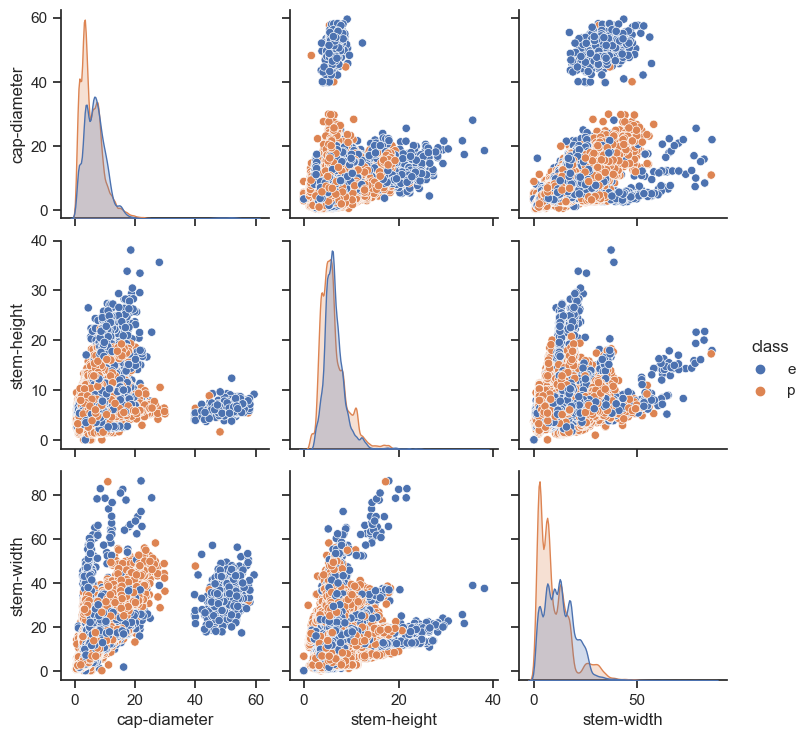

In [263]:
# Use this cell for plot 1

# YOUR CODE HERE
sns.set_theme(style="ticks")
sns.pairplot(imputed_mushrooms[numerical_features + ['class']], hue="class")

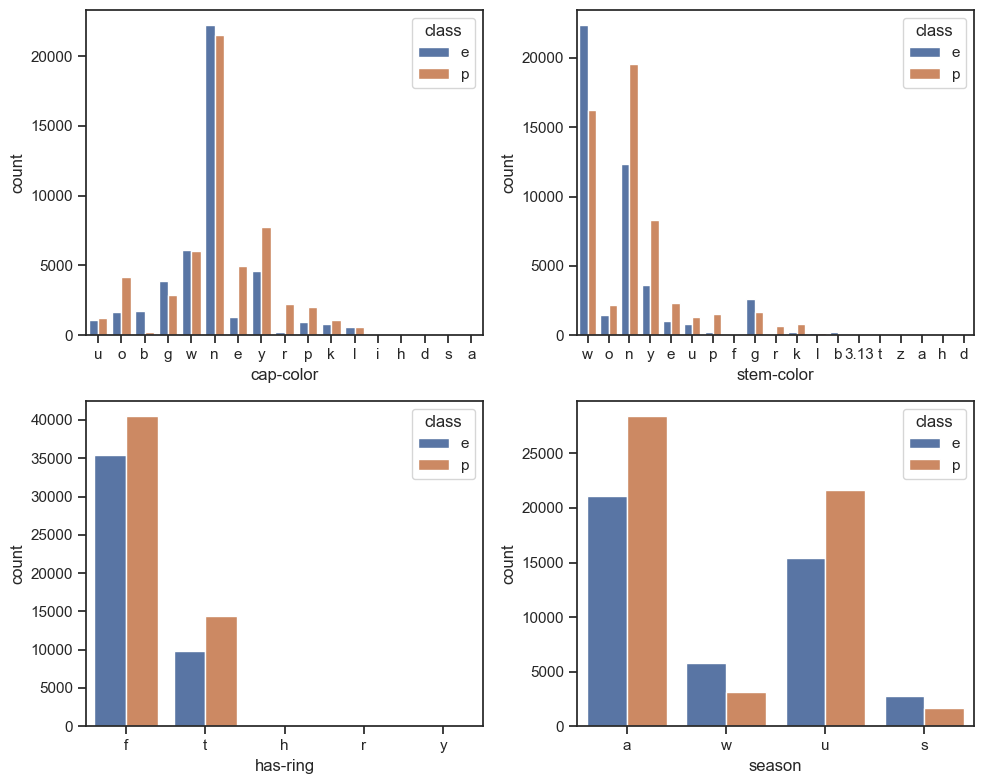

In [271]:
# Use this cell for plot 2


# YOUR CODE HERE
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
sns.countplot(data=imputed_mushrooms, x='cap-color', hue='class')

plt.subplot(2, 2, 2)
sns.countplot(data=imputed_mushrooms, x='stem-color', hue='class')


plt.subplot(2, 2, 3)
sns.countplot(data=imputed_mushrooms, x='has-ring', hue='class')

plt.subplot(2, 2, 4)
sns.countplot(data=imputed_mushrooms, x='season', hue='class')

plt.tight_layout()
plt.show()

#I checked the data in both imputed_mushrooms and mushrooms_train,
#and both contain some weird data, such as:
#---imputed_mushrooms:
#Unique values for 'stem-color':
#['w' 'o' 'n' 'y' 'e' 'u' 'p' 'f' 'g' 'r' 'k' 'l' 'b' '3.13' 't' 'z' 'a' 'h' 'd']
#Unique values for 'has-ring':
#['f' 't' 'h' 'r' 'y']

#---mushrooms_train":
#Unique values for 'stem-color':
#['w' 'o' 'n' 'y' 'e' 'u' 'p' 'f' 'g' 'r' 'k' 'l' 'b' '3.13' 't' 'z' 'a' 'h' 'd']
#Unique values for 'has-ring':
#['f' 't' 'h' 'r' 'y']

#However, I will not fix this, as it does not influence anything. 
#It is not my fault, and I do not have extra time to fix things that are not directly asked for in the assignment. 
#I hope this will not affect my grade.

### Exercise 2.2.4

Make the one_hot encoding for all categorical features using [Pandas get dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), and make a dataframe where you concatenate the numerical features and the `one_hot` categorical features. The resulting dataframe should have more than 100 features in total (of which more than 90% the result of the `one_hot` encodings of categorical features).

Split the data into `y` (the feature `class`) and `X` (all other features, except for `ID`) . You can directly use the pandas DataFrames for these, so we can keep the feature names readily available for inspection when using our trees later on.

Split this into train/test splits called `X_train`, `X_test`, `y_train`, `y_test` with test_size = 0.33 and random_state = 42.
(You can directly put your Pandas data frames into `train_test_split,` and the results should also be Pandas data frames.)

Make an instance of the class [AdaBoost](https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) called `clf`, and train it on X_train.

In [266]:
from sklearn.ensemble import AdaBoostClassifier

test_size = 0.33
random_state = 42

# YOUR CODE HERE
encoded_categorial = pd.get_dummies( imputed_mushrooms[categorical_features ]) #whitout clas column since it is target for learning model
encoded_fill_df = pd.concat([imputed_mushrooms['id'], imputed_mushrooms['class'], imputed_mushrooms[numerical_features], encoded_categorial], axis=1)

y = encoded_fill_df['class']
X = encoded_fill_df.drop(columns=['id', 'class']) #without id and class

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state
)

clf = AdaBoostClassifier()
clf.fit(X_train, y_train)

# Check encoding
#print(f"Total numb of features: {processed_mushrooms.shape[1]}")
#print(f"Percentage : {100 * encoded_categorial.shape[1] / processed_mushrooms.shape[1]:.2f}%")
#encoded_fill_df


AdaBoostClassifier()

In [267]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

In [268]:
# Use this to see if your results make any sense.
# Preferably, your accuracy would be higher than 70%

from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)
print(f"{confusion_matrix(y_test, y_pred)}")
print(f"Accuracy score of {accuracy_score(y_test, y_pred)}")

[[11090  3814]
 [ 3649 14447]]
Accuracy score of 0.7738484848484849


### Exercise 2.2.5

Take a look at the feature importances generated by the AdaBoost classifier. Did you expect this?


In [270]:
# Sorted feature importances:
sorted(
    list(zip(clf.feature_importances_, clf.feature_names_in_)),
    key=lambda x: x[0],
    reverse=True,
)

[(0.18, 'stem-width'),
 (0.12, 'stem-height'),
 (0.06, 'cap-diameter'),
 (0.04, 'stem-color_w'),
 (0.04, 'has-ring_f'),
 (0.04, 'ring-type_Unavailable'),
 (0.02, 'cap-shape_b'),
 (0.02, 'cap-shape_o'),
 (0.02, 'cap-shape_x'),
 (0.02, 'cap-color_b'),
 (0.02, 'cap-color_e'),
 (0.02, 'cap-color_n'),
 (0.02, 'cap-color_r'),
 (0.02, 'cap-color_y'),
 (0.02, 'gill-color_f'),
 (0.02, 'gill-color_g'),
 (0.02, 'gill-color_n'),
 (0.02, 'gill-color_u'),
 (0.02, 'gill-color_w'),
 (0.02, 'gill-color_y'),
 (0.02, 'stem-color_g'),
 (0.02, 'stem-color_l'),
 (0.02, 'stem-color_o'),
 (0.02, 'stem-color_p'),
 (0.02, 'stem-color_u'),
 (0.02, 'ring-type_r'),
 (0.02, 'ring-type_z'),
 (0.02, 'habitat_g'),
 (0.02, 'habitat_p'),
 (0.02, 'habitat_w'),
 (0.02, 'season_s'),
 (0.02, 'season_w'),
 (0.0, 'cap-shape_Unavailable'),
 (0.0, 'cap-shape_c'),
 (0.0, 'cap-shape_d'),
 (0.0, 'cap-shape_e'),
 (0.0, 'cap-shape_f'),
 (0.0, 'cap-shape_k'),
 (0.0, 'cap-shape_l'),
 (0.0, 'cap-shape_n'),
 (0.0, 'cap-shape_p'),
 (0.0,

It is clear that the 'stem-width' nad 'stem-height' have the greatest importance, I did not expect this, because I do not know anything about mushrooms. It is interesting that so many signs do not really contribute at all and have an importance of 0

### Bonus:

When making this assignment, I did some data leakage.
Where?

When imputing missing values (including the target one), or when scaling data before splitting into training and test samples.